# LAP — Laplace Approximated Posterior for the Mass-Spring-Damper System

**Reference:** Dass et al. (2016) *Laplace Based Approximate Posterior Inference for Differential Equation Models* ([arXiv:1607.07203](https://arxiv.org/pdf/1607.07203))

This notebook implements the full LAP pipeline for Bayesian parameter estimation of the Mass-Spring-Damper (MSD) system, estimating the damping factor $\delta$ and natural frequency $\omega_0$ from noisy position observations.

In [1]:
import numpy as np
import functools
import scipy.signal
from scipy.integrate import solve_ivp
from matplotlib import pyplot as pp
import matplotlib.pyplot as plt
import pickle
import torch

Python(95095) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


## 1. Data

We observe noisy position measurements $y_i = x(t_i) + \varepsilon_i$ where $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$, $\sigma = 0.1$.  
We use the **no external force** scenario with **sparsity level 100** (100 evenly-spaced observations over 60 s).

In [3]:
with open('/Users/anshgrover/AIDA3/PINN-tutorial/data/massdamper_data.pkl', 'rb') as f:
    data = pickle.load(f)

data_sampled_random_with_noise = data['data_sampled_random_with_noise']
model_name = 'No external force'
sparsity   = 'sparsity 1.667Hz'
t_obs = torch.tensor(data_sampled_random_with_noise[model_name][sparsity]['t'], dtype=torch.float64)
y_obs = torch.tensor(data_sampled_random_with_noise[model_name][sparsity]['x'], dtype=torch.float64)
n = len(t_obs)
p = 1

## 2. True Parameters and Analytical Solution

The MSD system with no external force obeys:
$$\ddot{x} + \frac{c}{m}\dot{x} + \frac{k}{m}x = 0$$

We reparametrise using:
- $\delta = \frac{c}{2m}$ — damping factor  
- $\omega_0 = \sqrt{\frac{k}{m}}$ — natural frequency

giving the equivalent ODE:
$$\ddot{x} = -2\delta\dot{x} - \omega_0^2 x$$

For the underdamped case ($\delta < \omega_0$), the analytical solution with $x(0)=1$, $\dot{x}(0)=0$ is:
$$x(t) = e^{-\delta t}\cos(\omega t) + \frac{\delta}{\omega}e^{-\delta t}\sin(\omega t), \quad \omega = \sqrt{\omega_0^2 - \delta^2}$$

delta  = 0.0750
omega0 = 0.3162


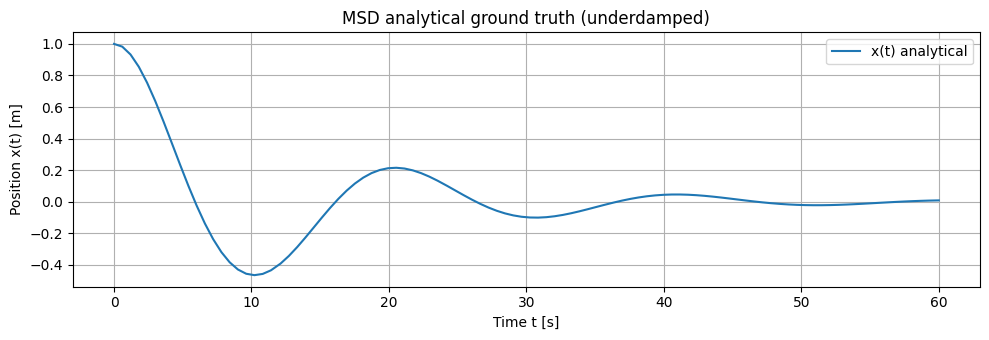

In [4]:
# ---------------------------
# Physical parameters
# ---------------------------
m_true = 2.0    # mass          [kg]
c_true = 0.3    # damping coeff [Ns/m]
k_true = 0.2    # spring const  [N/m]
delta_msd  = c_true / (2 * m_true)          # 0.075
omega0_msd = np.sqrt(k_true / m_true)       # 0.3162

print(f"delta  = {delta_msd:.4f}")
print(f"omega0 = {omega0_msd:.4f}")
x0     = [1.0, 0.0]
t_span     = (t_obs[0], t_obs[-1])

def mass_damper(delta,omega0,t): 
    omega = np.sqrt(omega0**2 - delta**2)
    phi = np.arctan(-delta/omega)
    A = 1/(2*np.cos(phi))
    coss = np.cos(phi+omega*t)
    exp = np.exp(-delta*t)
    y = exp*2*A*coss
    return y

y_exact = mass_damper(delta_msd, omega0_msd, t_obs)

pp.figure(figsize=(10, 3.5))
pp.plot(t_obs, y_exact, label='x(t) analytical')
pp.xlabel('Time t [s]')
pp.ylabel('Position x(t) [m]')
pp.title('MSD analytical ground truth (underdamped)')
pp.legend(); pp.grid(True); pp.tight_layout(); pp.show()

## 3. RK4 Step Size (Theorem 2)

**Theorem 2** (Dass et al.) requires the RK4 step size $h/m$ to satisfy:
$$\frac{h}{m} = O\left(n^{-5/(2K)}\right)$$
where $K=4$ is the order of the Runge-Kutta method. This ensures the numerical integration error is negligible relative to the statistical estimation error.

`m_sub` is the number of RK4 sub-steps taken between consecutive observation times (spaced $h$ apart). The actual step size passed to RK4 is $h / \texttt{m\_sub}$.

In [5]:
# ---------------------------
# Theorem 2: h/m_sub <= O(n^{-5/(2K)}),  K=4
# ---------------------------
n     = len(t_obs)
h     = t_obs[1] - t_obs[0]
K     = 4

theorem2_bound = n ** (-5 / (2 * K))
m_sub          = int(np.ceil(h / theorem2_bound))
step_size      = h / m_sub

print(f"n                = {n}")
print(f"h                = {h:.4f} s")
print(f"n^(-5/8)         = {theorem2_bound:.4f}  (Theorem 2 bound)")
print(f"m_sub required   = {m_sub}")
print(f"actual step size = {step_size:.4f} s")
print(f"Theorem 2 satisfied? {step_size <= theorem2_bound}")

n                = 100
h                = 0.6010 s
n^(-5/8)         = 0.0562  (Theorem 2 bound)
m_sub required   = 11
actual step size = 0.0546 s
Theorem 2 satisfied? True


## 4. ODE and RK4 Integration

The MSD ODE in state-space form with $y = [x, v]^\top$:
$$\dot{y} = f(y, t; \delta, \omega_0) = \begin{bmatrix} v \\ -2\delta v - \omega_0^2 x \end{bmatrix}$$

The RK4 update rule advances the state by one step $h$:
$$y_{i+1} = y_i + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

where $k_1, k_2, k_3, k_4$ are slope estimates at the start, two midpoints, and end of the interval.  
The implementation uses PyTorch so that **autograd can differentiate through the integrator** — needed for the Hessian computation later.

Max position error (LAP vs ground truth): 1.24e-09


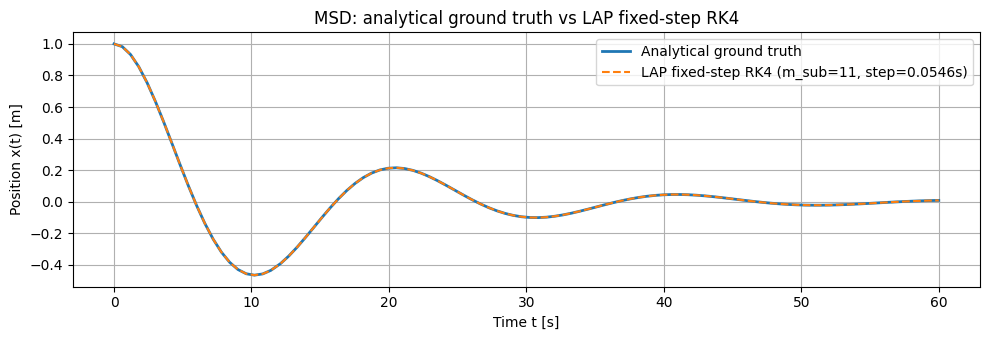

In [6]:
# ---------------------------
# ODE in PyTorch
# ---------------------------
def msd(t, y, delta, omega0):
    if not torch.is_tensor(y):
        y = torch.tensor(y, dtype=torch.float64)
    x, v = y[0], y[1]
    return torch.stack([v, -2*delta*v - omega0**2*x])

# ---------------------------
# RK4 in PyTorch — autograd tracks through this
# ---------------------------
def rk4_integrate(f, t_eval, y0, m_sub):
    if not torch.is_tensor(y0):
        y0 = torch.tensor(y0, dtype=torch.float64)
    if not torch.is_tensor(t_eval):
        t_eval = torch.tensor(t_eval, dtype=torch.float64)

    Y = [y0]
    y = y0
    for i in range(1, len(t_eval)):
        dt = (t_eval[i] - t_eval[i-1]).item()
        h  = dt / m_sub
        yi = y
        ti = t_eval[i-1].item()
        for _ in range(m_sub):
            k1 = f(ti,       yi            )
            k2 = f(ti + h/2, yi + h/2 * k1)
            k3 = f(ti + h/2, yi + h/2 * k2)
            k4 = f(ti + h,   yi + h   * k3)
            yi = yi + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
            ti += h
        y = yi
        Y.append(y)
    return torch.stack(Y)


msd_fixed = functools.partial(msd,
                              delta=torch.tensor(delta_msd, dtype=torch.float64),
                              omega0=torch.tensor(omega0_msd, dtype=torch.float64))

Y_lap  = rk4_integrate(msd_fixed, t_obs, x0, m_sub)
x_pred = Y_lap[:, 0]


err = np.max(np.abs(x_pred.detach().numpy() - y_exact.numpy()))
print(f"Max position error (LAP vs ground truth): {err:.2e}")

pp.figure(figsize=(10, 3.5))
pp.plot(t_obs, y_exact, lw=2,  label='Analytical ground truth')
pp.plot(t_obs, x_pred.detach().numpy(),  '--',  label=f'LAP fixed-step RK4 (m_sub={m_sub}, step={step_size:.4f}s)')
pp.xlabel('Time t [s]')
pp.ylabel('Position x(t) [m]')
pp.title('MSD: analytical ground truth vs LAP fixed-step RK4')
pp.legend(); pp.grid(True); pp.tight_layout(); pp.show()

## 5. Mean Squared Residual $g_n$

$$g_n(x_1, \theta) = \frac{1}{n}\sum_{i=1}^{n}\|y_i - x_i(\theta, x_1)\|^2$$

This is the base quantity everything else builds on. At the true $\theta$ and $x_1$ it should be close to $\sigma^2 = 0.01$.

In [7]:
n = len(t_obs)
p = 1
print(f"n={n}, p={p}")

n=100, p=1


In [8]:
def compute_gn(x_pred, y_obs):
    if not torch.is_tensor(x_pred):
        x_pred = torch.tensor(x_pred, dtype=torch.float64)
    if not torch.is_tensor(y_obs):
        y_obs  = torch.tensor(y_obs,  dtype=torch.float64)
    return torch.mean((y_obs - x_pred)**2)
gn_val = compute_gn(x_pred, y_obs)
print(f"g_n at true theta and true x1 = {gn_val:.6f}")
print(f"Expected ~sigma^2 = {0.1**2:.4f}")

g_n at true theta and true x1 = 0.009230
Expected ~sigma^2 = 0.0100


In [10]:
# ---------------------------
# g̈_n via autograd through our own RK4
# ---------------------------
def compute_gn_dd_autograd(x1_val, theta):
    delta, omega0 = theta

    x1          = torch.tensor(x1_val, requires_grad=True, dtype=torch.float64)
    y0          = torch.stack([x1, torch.tensor(0.0, dtype=torch.float64)])

    f      = lambda t, y: msd(t, y, delta, omega0)
    Y      = rk4_integrate(f, t_obs, y0, m_sub)
    x_pred = Y[:, 0]

    gn         = compute_gn(x_pred, y_obs)
    dgn        = torch.autograd.grad(gn, x1, create_graph=True)[0]
    d2gn       = torch.autograd.grad(dgn, x1)[0]

    return d2gn.item()

# ---------------------------
# Test
# ---------------------------
theta_true = np.array([delta_msd, omega0_msd])
gn_dd_val = compute_gn_dd_autograd(x0[0], theta_true)
print(f"g̈_n via autograd = {gn_dd_val:.6f}")

g̈_n via autograd = 0.145248


## 6. Prior Hyperparameters

| Prior | Distribution | Parameters | Role |
|-------|-------------|------------|------|
| $\tau^2 = 1/\sigma^2$ | $\text{Gamma}(a, b)$ | $a=0.1$, $b=0.01$ | uninformative noise precision prior |
| $x_1 \mid \tau^2$ | $\mathcal{N}(\mu_{x_1},\ c\tau^{-2}I_p)$ | $\mu_{x_1}=y_1$, $c=100$ | weak prior on initial condition |
| $\theta$ | Uniform | — | flat prior on parameters |

The Gamma prior on $\tau^2$ is chosen for **conjugacy** — it allows $\tau^2$ to be integrated out analytically in Section 3.3.

In [11]:
from scipy.optimize import minimize_scalar
# ---------------------------
# Prior hyperparameters
# ---------------------------
mu_x1 = y_obs[0].item()    # prior mean for x_1 = first noisy observation
c     = 100.0       # weak prior on x_1
a     = 0.1         # Gamma prior shape on tau^2
b     = 0.01        # Gamma prior rate on tau^2


# ---------------------------
# Step 2: Find x_hat_1(theta)
# Minimize: n*g_n(x1, theta) + (x1 - mu_x1)^2 / c
# x1 is scalar (initial position), velocity fixed at 0
# ---------------------------

def objective_x1(x1, theta):
    delta, omega0  = theta
    f              = functools.partial(msd, delta=delta, omega0=omega0)
    Y              = rk4_integrate(f, t_obs, [x1, 0.0], m_sub)
    x_pred         = Y[:, 0]
    gn             = compute_gn(x_pred, y_obs)
    penalty        = (x1 - mu_x1)**2 / c
    return (n * gn).item() + penalty

# ---------------------------
# Test at true parameters
# ---------------------------
bounds_x1 = (y_obs.min().item(), y_obs.max().item())

result = minimize_scalar(objective_x1, bounds=bounds_x1,
                         method='bounded', args=(theta_true,))
x1_hat = result.x

print(f"x1_hat          = {x1_hat:.6f}")
print(f"true x1         = {x0[0]:.6f}")
print(f"mu_x1           = {mu_x1:.6f}")
print(f"objective value = {result.fun:.6f}")

x1_hat          = 0.964120
true x1         = 1.000000
mu_x1           = 1.030245
objective value = 0.913611


## 7. Laplace Approximation — Finding $\hat{x}_1(\theta)$

### Why we need to marginalise $x_1$

The full posterior is $\pi(\theta, \tau^2, x_1 \mid y_n)$. We cannot compute $\pi(\theta \mid y_n)$ analytically because $x_1$ enters through the ODE nonlinearly. We need to integrate it out:
$$\int \pi(x_1 \mid \tau^2)\, L(\theta, \tau^2, x_1)\, dx_1$$

**Laplace approximation** replaces this integral with a Gaussian centred at the mode $\hat{x}_1$:
$$\hat{x}_1(\theta) = \underset{x_1}{\text{argmin}}\left[n\cdot g_n(x_1, \theta) + \frac{\|x_1 - \mu_{x_1}\|^2}{c}\right]$$

This is a scalar optimisation since $p=1$. We use `torch.optim.LBFGS` so the computation graph stays intact for autograd.

In [12]:
def find_x1hat_torch(theta):
    delta, omega0 = theta[0], theta[1]
    x1 = torch.tensor([mu_x1], requires_grad=True, dtype=torch.float64)
    optimizer = torch.optim.LBFGS([x1], lr=1.0, max_iter=100)

    def closure():
        optimizer.zero_grad()
        f      = functools.partial(msd, delta=delta, omega0=omega0)
        Y      = rk4_integrate(f, t_obs, torch.stack([x1[0], torch.tensor(0.0, dtype=torch.float64)]), m_sub)
        x_pred = Y[:, 0]
        gn     = compute_gn(x_pred, y_obs)
        loss   = n * gn + (x1[0] - mu_x1)**2 / c
        loss.backward()
        return loss

    optimizer.step(closure)
    return x1[0]

find_x1hat_torch(theta_true)

tensor(0.9641, dtype=torch.float64, grad_fn=<SelectBackward0>)

## 8. Computing $u(\theta)$ and $v(\theta)$

After finding $\hat{x}_1$:

**$u(\theta)$** — weighted sum of squared residuals at the optimal initial condition:
$$u(\theta) = n\cdot g_n(\hat{x}_1) + \frac{\|\hat{x}_1 - \mu_{x_1}\|^2}{c}$$

**$v(\theta)$** — log-determinant of the Laplace curvature. For $p=1$ this is a scalar:
$$H = n\ddot{g}_n(\hat{x}_1) + \frac{2}{c}, \qquad v = \log H$$

where $\ddot{g}_n = d^2g_n/dx_1^2$ is computed via **autograd through the RK4 integrator**.

In [13]:
def compute_u(x1_hat, theta):
    delta, omega0 = theta
    f             = functools.partial(msd, delta=delta, omega0=omega0)
    Y             = rk4_integrate(f, t_obs, [x1_hat, 0.0], m_sub)
    x_pred        = Y[:, 0]
    gn            = compute_gn(x_pred, y_obs)
    u             = n * gn + (x1_hat - mu_x1)**2 / c
    return u, x_pred

u_val, x_pred_hat = compute_u(x1_hat, theta_true)

print(f"u(theta) = {u_val:.6f}")

u(theta) = 0.913611


In [14]:
def compute_v(x1_hat, theta):
    gn_dd = compute_gn_dd_autograd(x1_hat, theta)
    H     = n * gn_dd + 2.0 / c     # scalar since p=1
    return np.log(H)

print(compute_v(x1_hat, theta_true))

2.677232142762964


## 9. Log Posterior $\log\pi(\theta \mid y_n)$

### Marginalising $\tau^2$ by conjugacy (Section 3.3)

Since $\tau^2 \sim \text{Gamma}(a, b)$ and the likelihood is Gaussian, the conditional posterior is:
$$\tau^2 \mid \theta, y_n \sim \text{Gamma}\!\left(\frac{np}{2}+a,\ \frac{u(\theta)}{2}+b\right)$$

Integrating this out analytically yields **Equation (7)**:
$$\log\pi(\theta \mid y_n) = \text{const} - \left(\frac{np}{2}+a\right)\log\left(\frac{u(\theta)}{2}+b\right) - \frac{1}{2}v(\theta)$$

The uniform prior on $\theta$ contributes $\log\pi(\theta) = 0$.

In [15]:
def lap_posterior(theta):
    delta  = theta[0]
    omega0 = theta[1]
    theta_t = (delta, omega0)

    # --- find x̂_1(θ) ---
    x1_hat = find_x1hat_torch(theta).detach()

    # --- u(θ) ---
    u, _ = compute_u(x1_hat, theta_t)
    if u <= 0:
        return torch.tensor(-torch.inf, dtype=torch.float64)

    # --- v(θ) ---
    gn_dd = compute_gn_dd_autograd(x1_hat.item(), theta_t)
    H     = n * gn_dd + 2.0 / c
    if H <= 0:
        return torch.tensor(-torch.inf, dtype=torch.float64)
    v = torch.log(torch.tensor(H, dtype=torch.float64))

    # --- log π(θ|y_n) ---
    log_pi = -(n * p / 2 + a) * torch.log(u / 2 + b) - 0.5 * v
    return log_pi

def lap_posterior_u(theta):
    delta  = theta[0]
    omega0 = theta[1]
    theta_t = (delta, omega0)

    # --- find x̂_1(θ) ---
    x1_hat = find_x1hat_torch(theta).detach()

    # --- u(θ) ---
    u, _ = compute_u(x1_hat, theta_t)
    if u <= 0:
        return torch.tensor(-torch.inf, dtype=torch.float64)

    # --- v(θ) ---
    gn_dd = compute_gn_dd_autograd(x1_hat.item(), theta_t)
    H     = n * gn_dd + 2.0 / c
    if H <= 0:
        return torch.tensor(-torch.inf, dtype=torch.float64)
    v = torch.log(torch.tensor(H, dtype=torch.float64))

    # --- log π(θ|y_n) ---
    log_pi = -(n * p / 2 + a) * torch.log(u / 2 + b) - 0.5 * v
    return log_pi, u

In [16]:
print(lap_posterior(theta_true))

tensor(36.8297, dtype=torch.float64)


In [17]:
33.7 - 0.5 * 2.677232142762964

32.36138392861852

In [18]:
print(lap_posterior([0.1,0.1]))

tensor(-66.0359, dtype=torch.float64)


## 10. Finding a Good $\theta^0$

Before the automatic grid we need a $\theta^0$ near the posterior mode. We use a three-stage coarse-to-fine sweep — each stage narrows the search window around the best point found so far — without using the true parameter values as input.

In [19]:
# --- construct grid ---
delta_grid  = np.linspace(0.01, 0.2,  10)
omega0_grid = np.linspace(0.1,  0.6,  10)

log_pi = np.zeros((10, 10))

for i, delta in enumerate(delta_grid):
    for j, omega0 in enumerate(omega0_grid):
        log_pi[j, i] = lap_posterior([delta, omega0])
        print(f"({i},{j}) delta={delta:.3f} omega0={omega0:.3f} → {log_pi[j,i]:.2f}")

# --- normalize ---
log_pi_shifted = log_pi - np.max(log_pi)   # subtract max for numerical stability
pi             = np.exp(log_pi_shifted)
pi            /= pi.sum()                   # normalize to sum to 1

# --- MAP estimate (peak of the grid) ---
j_map, i_map = np.unravel_index(np.argmax(pi), pi.shape)
delta_map    = delta_grid[i_map]
omega0_map   = omega0_grid[j_map]

print(f"delta  MAP = {delta_map:.4f}  (true: {delta_msd:.4f})")
print(f"omega0 MAP = {omega0_map:.4f}  (true: {omega0_msd:.4f})")

# --- marginal means ---
delta_mean  = np.sum(pi.sum(axis=0) * delta_grid)
omega0_mean = np.sum(pi.sum(axis=1) * omega0_grid)

print(f"delta  mean = {delta_mean:.4f}")
print(f"omega0 mean = {omega0_mean:.4f}")

(0,0) delta=0.010 omega0=0.100 → -66.87
(0,1) delta=0.010 omega0=0.156 → -62.87
(0,2) delta=0.010 omega0=0.211 → -59.22
(0,3) delta=0.010 omega0=0.267 → -41.12
(0,4) delta=0.010 omega0=0.322 → -48.64
(0,5) delta=0.010 omega0=0.378 → -61.31
(0,6) delta=0.010 omega0=0.433 → -67.67
(0,7) delta=0.010 omega0=0.489 → -68.58
(0,8) delta=0.010 omega0=0.544 → -69.43
(0,9) delta=0.010 omega0=0.600 → -69.30
(1,0) delta=0.031 omega0=0.100 → -64.88
(1,1) delta=0.031 omega0=0.156 → -57.99
(1,2) delta=0.031 omega0=0.211 → -47.07
(1,3) delta=0.031 omega0=0.267 → -15.77
(1,4) delta=0.031 omega0=0.322 → -21.40
(1,5) delta=0.031 omega0=0.378 → -49.09
(1,6) delta=0.031 omega0=0.433 → -62.48
(1,7) delta=0.031 omega0=0.489 → -66.29
(1,8) delta=0.031 omega0=0.544 → -68.20
(1,9) delta=0.031 omega0=0.600 → -68.40
(2,0) delta=0.052 omega0=0.100 → -64.62
(2,1) delta=0.052 omega0=0.156 → -55.99
(2,2) delta=0.052 omega0=0.211 → -39.19
(2,3) delta=0.052 omega0=0.267 → 1.98
(2,4) delta=0.052 omega0=0.322 → 9.77
(2,5

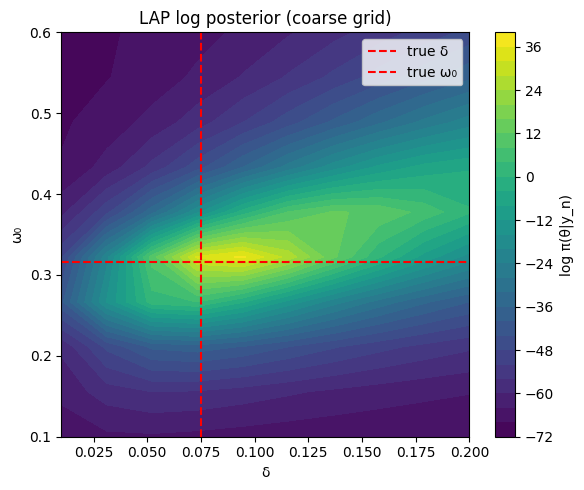

In [20]:
pp.figure(figsize=(6,5))
pp.contourf(delta_grid, omega0_grid, log_pi, levels=30, cmap='viridis')
pp.colorbar(label='log π(θ|y_n)')
pp.axvline(delta_msd,  color='r', linestyle='--', label='true δ')
pp.axhline(omega0_msd, color='r', linestyle='--', label='true ω₀')
pp.xlabel('δ'); pp.ylabel('ω₀')
pp.title('LAP log posterior (coarse grid)')
pp.legend(); pp.tight_layout(); pp.show()

## 11. Hessian and Reparametrisation (Section 3.4)

We compute the **negative Hessian** of $\log\pi(\theta \mid y_n)$ at $\theta^0$:
$$\hat{\Sigma} = H^{-1}, \quad H = -\nabla^2_{\theta}\log\pi(\theta^0 \mid y_n)$$

Eigendecomposing $H = U\Lambda U^\top$ gives the reparametrisation:
$$\theta(z) = \theta^0 + U\Lambda^{-1/2}z$$

In $z$-space the posterior is approximately spherical. Scanning $z \in [-4, 4]^q$ is guaranteed to cover $\pm 4$ posterior standard deviations.

> **Paper (§3.4):** If $H$ is not positive definite, replace negative eigenvalues with the minimum positive eigenvalue.

In [21]:

theta0 = torch.tensor(theta_true, dtype=torch.float64)

H = torch.autograd.functional.hessian(lap_posterior, torch.tensor(theta0, dtype=torch.float64))
neg_H = -H.numpy()

# eigendecompose
eigenvalues, U = np.linalg.eigh(neg_H)
eigenvalues    = np.maximum(eigenvalues, 1e-8)
A              = np.matmul(U, np.diag(eigenvalues ** -0.5))

# --- Step 2: coarse scan over z ∈ [-4, 4]^q ---
M1    = 3
eta   = 1e-5
z_1d  = np.linspace(-4, 4, 2*M1 + 1)

A_bounds = []   # will hold [A_i, B_i] for each dimension
B_bounds = []

print(z_1d)
for dim in range(len(theta0)):
    active = []
    for z_val in z_1d:
        z          = np.zeros(len(theta0))
        z[dim]     = z_val
        theta_test = theta0 + A @ z
        lp        = lap_posterior(theta_test)
        if lp > np.log(eta):
            active.append(z_val)
    A_bounds.append(min(active) if active else -4)
    B_bounds.append(max(active) if active else  4)

print(f"Coarse scan bounds in z-space:")
for i in range(len(theta0)):
    print(f"  z[{i}]: [{A_bounds[i]:.2f}, {B_bounds[i]:.2f}]")

/var/folders/qb/4gqyhj5d15728855vcb9k79w0000gn/T/ipykernel_60069/203404650.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  H = torch.autograd.functional.hessian(lap_posterior, torch.tensor(theta0, dtype=torch.float64))


[-4.         -2.66666667 -1.33333333  0.          1.33333333  2.66666667
  4.        ]
Coarse scan bounds in z-space:
  z[0]: [-4.00, 4.00]
  z[1]: [-4.00, 4.00]


In [22]:
M2     = 10
z0_1d  = np.linspace(A_bounds[0], B_bounds[0], 2*M2 + 1)
z1_1d  = np.linspace(A_bounds[1], B_bounds[1], 2*M2 + 1)

Z0, Z1  = np.meshgrid(z0_1d, z1_1d)
log_pi  = np.zeros_like(Z0)
u_grid = np.zeros_like(Z0)

In [23]:
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [25]:
for i in range(Z0.shape[0]):
    for j in range(Z0.shape[1]):
        z          = np.array([Z0[i,j], Z1[i,j]])
        theta_ij   = theta0 + A @ z
        log_pi[i,j], u_grid[i,j] = lap_posterior_u(theta_ij)
        print(f"({i},{j}) θ=({theta_ij[0]:.3f},{theta_ij[1]:.3f}) → {log_pi[i,j]:.2f}")


(0,0) θ=(0.100,0.327) → 34.82
(0,1) θ=(0.099,0.325) → 35.40
(0,2) θ=(0.097,0.324) → 35.93
(0,3) θ=(0.096,0.322) → 36.39
(0,4) θ=(0.094,0.320) → 36.77
(0,5) θ=(0.093,0.318) → 37.07
(0,6) θ=(0.091,0.316) → 37.28
(0,7) θ=(0.090,0.314) → 37.39
(0,8) θ=(0.089,0.312) → 37.41
(0,9) θ=(0.087,0.310) → 37.31
(0,10) θ=(0.086,0.308) → 37.09
(0,11) θ=(0.084,0.306) → 36.76
(0,12) θ=(0.083,0.304) → 36.29
(0,13) θ=(0.081,0.302) → 35.70
(0,14) θ=(0.080,0.300) → 34.97
(0,15) θ=(0.078,0.299) → 34.11
(0,16) θ=(0.077,0.297) → 33.10
(0,17) θ=(0.075,0.295) → 31.96
(0,18) θ=(0.074,0.293) → 30.69
(0,19) θ=(0.072,0.291) → 29.28
(0,20) θ=(0.071,0.289) → 27.74
(1,0) θ=(0.099,0.328) → 34.97
(1,1) θ=(0.098,0.326) → 35.60
(1,2) θ=(0.096,0.324) → 36.17
(1,3) θ=(0.095,0.322) → 36.67
(1,4) θ=(0.093,0.320) → 37.09
(1,5) θ=(0.092,0.319) → 37.44
(1,6) θ=(0.090,0.317) → 37.69
(1,7) θ=(0.089,0.315) → 37.85
(1,8) θ=(0.087,0.313) → 37.91
(1,9) θ=(0.086,0.311) → 37.85
(1,10) θ=(0.085,0.309) → 37.67
(1,11) θ=(0.083,0.307) → 37.

In [26]:
# --- normalize ---
log_pi_shifted = log_pi - np.max(log_pi)   # subtract max for numerical stability
pi             = np.exp(log_pi_shifted)
pi            /= pi.sum()                   # proper probability weights

# --- draw θ^(i) samples from the discrete grid ---
N_samples   = 1000
flat_pi     = pi.flatten()
flat_idx    = np.random.choice(len(flat_pi), size=N_samples, p=flat_pi)
i_idx, j_idx = np.unravel_index(flat_idx, pi.shape)

theta_samples = np.array([
    (theta0 + A @ np.array([Z0[i,j], Z1[i,j]])).numpy()
    for i, j in zip(i_idx, j_idx)
])   # (N_samples, 2)

# --- Step 3: for each θ^(i), draw τ²^(i) ~ Gamma(np/2+a, u(θ^(i))/2+b) ---
u_flat     = u_grid.flatten()[flat_idx]
tau2_samples = np.array([
    np.random.gamma(
        shape = n*p/2 + a,
        scale = 1.0 / (u_flat[i] / 2 + b)
    )
    for i in range(N_samples)
])

In [27]:
tau2_samples.shape

(1000,)

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
19
19
19
19
1

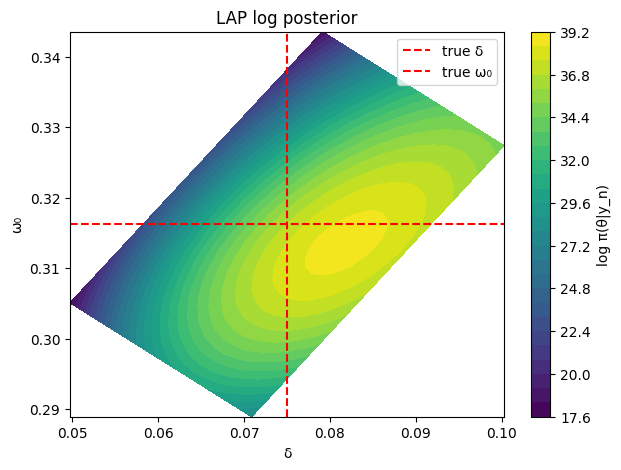

In [28]:
delta_grid_theta  = np.zeros_like(Z0)
omega0_grid_theta = np.zeros_like(Z1)

for i in range(Z0.shape[0]):
    for j in range(Z0.shape[1]):
        print(i)
        z = np.array([Z0[i,j], Z1[i,j]])
        theta_ij = (theta0 + A @ z).numpy()
        delta_grid_theta[i][j]  = theta_ij[0]
        omega0_grid_theta[i][j] = theta_ij[1]
print(delta_grid)
pp.figure(figsize=(7,5))
pp.contourf(delta_grid_theta, omega0_grid_theta, log_pi, levels=30, cmap='viridis')
pp.colorbar(label='log π(θ|y_n)')
pp.axvline(delta_msd,  color='r', linestyle='--', label='true δ')
pp.axhline(omega0_msd, color='r', linestyle='--', label='true ω₀')
pp.xlabel('δ'); pp.ylabel('ω₀')
pp.title('LAP log posterior')
pp.legend()

In [29]:
delta_mean  = np.average(theta_samples[:,0])
omega0_mean = np.average(theta_samples[:,1])
delta_std   = np.std(theta_samples[:,0])
omega0_std  = np.std(theta_samples[:,1])

print(f"δ:   true={delta_msd:.4f}  est={delta_mean:.4f}  std={delta_std:.4f}")
print(f"ω₀:  true={omega0_msd:.4f}  est={omega0_mean:.4f}  std={omega0_std:.4f}")

δ:   true=0.0750  est=0.0823  std=0.0056
ω₀:  true=0.3162  est=0.3143  std=0.0055


Text(0.5, 1.0, 'Marginal posterior ω₀')

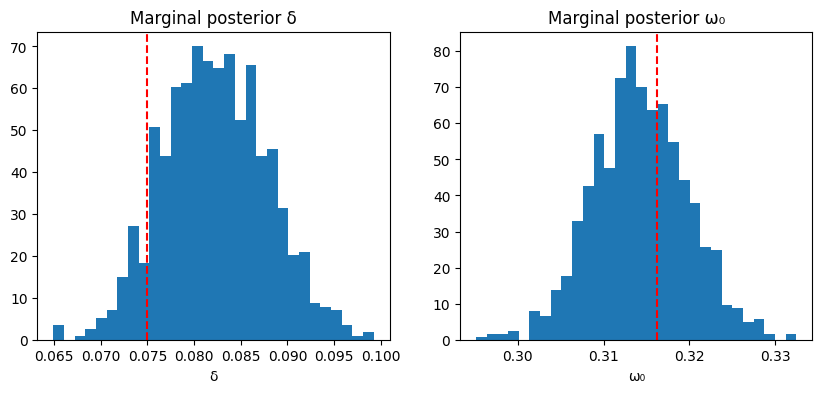

In [30]:
pp.figure(figsize=(10,4))
pp.subplot(1,2,1)
pp.hist(theta_samples[:,0], bins=30, density=True)
pp.axvline(delta_msd, color='r', linestyle='--', label='true δ')
pp.xlabel('δ'); pp.title('Marginal posterior δ')

pp.subplot(1,2,2)
pp.hist(theta_samples[:,1], bins=30, density=True)
pp.axvline(omega0_msd, color='r', linestyle='--', label='true ω₀')
pp.xlabel('ω₀'); pp.title('Marginal posterior ω₀')

In [31]:
delta_ci  = np.percentile(theta_samples[:,0], [2.5, 97.5])
omega0_ci = np.percentile(theta_samples[:,1], [2.5, 97.5])

print(f"δ   95% CI: [{delta_ci[0]:.4f}, {delta_ci[1]:.4f}]  true={delta_msd:.4f}")
print(f"ω₀  95% CI: [{omega0_ci[0]:.4f}, {omega0_ci[1]:.4f}]  true={omega0_msd:.4f}")

δ   95% CI: [0.0723, 0.0933]  true=0.0750
ω₀  95% CI: [0.3037, 0.3252]  true=0.3162


In [32]:
sigma_samples = 1.0 / np.sqrt(tau2_samples)
print(f"σ estimate: {np.mean(sigma_samples):.4f} ± {np.std(sigma_samples):.4f}  true=0.1")

σ estimate: 0.0965 ± 0.0073  true=0.1


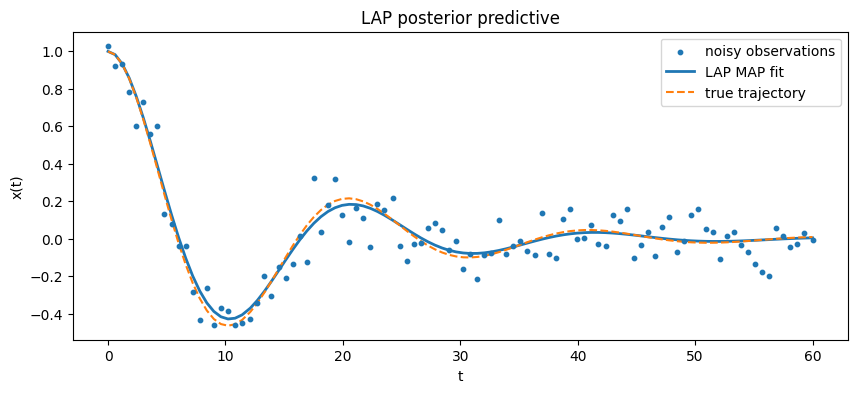

In [33]:
# use MAP estimate
j_map, i_map  = np.unravel_index(np.argmax(pi), pi.shape)
theta_map     = (theta0 + A @ np.array([Z0[j_map,i_map], Z1[j_map,i_map]])).numpy()

f      = functools.partial(msd, delta=theta_map[0], omega0=theta_map[1])
Y_map  = rk4_integrate(f, t_obs, x0, m_sub)

pp.figure(figsize=(10,4))
pp.scatter(t_obs, y_obs.numpy(), s=10, label='noisy observations', zorder=3)
pp.plot(t_obs, Y_map[:,0].detach().numpy(), lw=2, label='LAP MAP fit')
pp.plot(t_obs, y_exact, '--', label='true trajectory')
pp.xlabel('t'); pp.ylabel('x(t)')
pp.title('LAP posterior predictive')
pp.legend()

## 12. Full LAP Sampling (Section 3.4)

**Step 1 — Coarse scan** over $z \in [-4, 4]^q$ with $M_1$ half-steps.  
For each $z$, evaluate $\log\pi(\theta(z) \mid y_n)$. Retain bounds $[A_i, B_i]$ where $\log\pi > \log\eta$.

**Step 2 — Fine grid** over $[A_i, B_i]$ with $M_2$ half-steps. Normalise and draw:
$$\theta^{(1)}, \ldots, \theta^{(N)} \overset{\text{iid}}{\sim} \pi^d(\theta \mid y_n)$$

**Step 3 — Sample $\tau^2$** for each $\theta^{(i)}$ using conjugacy:
$$\tau^{2(i)} \sim \text{Gamma}\!\left(\frac{np}{2}+a,\ \frac{u(\theta^{(i)})}{2}+b\right)$$

In [34]:
def coarse_to_fine_sweep(delta_range, omega0_range, n_points=5):
    best_lp    = -np.inf
    best_theta = None
    
    for d in np.linspace(*delta_range,  n_points):
        for w in np.linspace(*omega0_range, n_points):
            lp = lap_posterior(torch.tensor([d, w], dtype=torch.float64)).item()
            if lp > best_lp:
                best_lp    = lp
                best_theta = np.array([d, w])
    
    print(f"best: delta={best_theta[0]:.4f}, omega0={best_theta[1]:.4f}, log_pi={best_lp:.2f}")
    return best_theta, best_lp

# stage 1
best1, _ = coarse_to_fine_sweep((0.01, 0.2), (0.1, 0.6), n_points=5)

# stage 2
best2, _ = coarse_to_fine_sweep(
    (best1[0] - 0.05, best1[0] + 0.05),
    (best1[1] - 0.10, best1[1] + 0.10),
    n_points=5
)

# stage 3
best3, _ = coarse_to_fine_sweep(
    (best2[0] - 0.01, best2[0] + 0.01),
    (best2[1] - 0.02, best2[1] + 0.02),
    n_points=5
)

theta0 = torch.tensor(best3, dtype=torch.float64)

best: delta=0.1050, omega0=0.3500, log_pi=25.03
best: delta=0.0800, omega0=0.3000, log_pi=34.61
best: delta=0.0800, omega0=0.3100, log_pi=38.55


In [35]:
print(theta0)

tensor([0.0800, 0.3100], dtype=torch.float64)


In [36]:
# Full LAP function
def LAP(theta0):

    H = torch.autograd.functional.hessian(lap_posterior, torch.tensor(theta0, dtype=torch.float64))
    neg_H = -H.numpy()

    # eigendecompose
    eigenvalues, U = np.linalg.eigh(neg_H)
    min_pos     = eigenvalues[eigenvalues > 0].min()
    eigenvalues = np.where(eigenvalues <= 0, min_pos, eigenvalues)
    A              = np.matmul(U, np.diag(eigenvalues ** -0.5))

    # --- Step 2: coarse scan over z ∈ [-4, 4]^q ---
    M1    = 3
    eta   = 1e-5
    z_1d  = np.linspace(-4, 4, 2*M1 + 1)

    A_bounds = []   # will hold [A_i, B_i] for each dimension
    B_bounds = []

    print(z_1d)
    for dim in range(len(theta0)):
        active = []
        for z_val in z_1d:
            z          = np.zeros(len(theta0))
            z[dim]     = z_val
            theta_test = theta0 + A @ z
            lp        = lap_posterior(theta_test)
            if lp > np.log(eta):
                active.append(z_val)
        A_bounds.append(min(active) if active else -4)
        B_bounds.append(max(active) if active else  4)

    print(f"Coarse scan bounds in z-space:")
    for i in range(len(theta0)):
        print(f"  z[{i}]: [{A_bounds[i]:.2f}, {B_bounds[i]:.2f}]")

    M2     = 10
    z0_1d  = np.linspace(A_bounds[0], B_bounds[0], 2*M2 + 1)
    z1_1d  = np.linspace(A_bounds[1], B_bounds[1], 2*M2 + 1)

    Z0, Z1  = np.meshgrid(z0_1d, z1_1d)
    log_pi  = np.zeros_like(Z0)
    u_grid = np.zeros_like(Z0)

    for i in range(Z0.shape[0]):
        for j in range(Z0.shape[1]):
            z          = np.array([Z0[i,j], Z1[i,j]])
            theta_ij   = theta0 + A @ z
            lp, u        = lap_posterior_u(theta_ij)
            log_pi[i,j]  = float(lp)
            u_grid[i,j]  = float(u)
            print(f"({i},{j}) θ=({theta_ij[0]:.3f},{theta_ij[1]:.3f}) → {log_pi[i,j]:.2f}")
    
    # --- normalize ---
    log_pi_shifted = log_pi - np.max(log_pi)   # subtract max for numerical stability
    pi             = np.exp(log_pi_shifted)
    pi            /= pi.sum()                   # proper probability weights

    # --- draw θ^(i) samples from the discrete grid ---
    N_samples   = 1000
    flat_pi     = pi.flatten()
    flat_idx    = np.random.choice(len(flat_pi), size=N_samples, p=flat_pi)
    i_idx, j_idx = np.unravel_index(flat_idx, pi.shape)

    theta_samples = np.array([
        (theta0 + A @ np.array([Z0[i,j], Z1[i,j]]))
        for i, j in zip(i_idx, j_idx)
    ])   # (N_samples, 2)

    # --- Step 3: for each θ^(i), draw τ²^(i) ~ Gamma(np/2+a, u(θ^(i))/2+b) ---
    u_flat     = u_grid.flatten()[flat_idx]
    tau2_samples = np.array([
        np.random.gamma(
            shape = n*p/2 + a,
            scale = 1.0 / (u_flat[i] / 2 + b)
        )
        for i in range(N_samples)
    ])

    lp, u = lap_posterior_u(theta_ij)
    log_pi[i,j] = float(lp)
    u_grid[i,j] = float(u)

    return tau2_samples, theta_samples,Z0, Z1, A, log_pi, u_grid

In [37]:
print(theta0)
tau2_samples, theta_samples,Z0, Z1, A, log_pi, u_grid = LAP(theta0)

tensor([0.0800, 0.3100], dtype=torch.float64)


/var/folders/qb/4gqyhj5d15728855vcb9k79w0000gn/T/ipykernel_60069/2584707755.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  H = torch.autograd.functional.hessian(lap_posterior, torch.tensor(theta0, dtype=torch.float64))


[-4.         -2.66666667 -1.33333333  0.          1.33333333  2.66666667
  4.        ]
Coarse scan bounds in z-space:
  z[0]: [-4.00, 4.00]
  z[1]: [-4.00, 4.00]
(0,0) θ=(0.107,0.318) → 30.22
(0,1) θ=(0.105,0.316) → 30.54
(0,2) θ=(0.103,0.314) → 30.81
(0,3) θ=(0.102,0.312) → 31.03
(0,4) θ=(0.100,0.311) → 31.18
(0,5) θ=(0.098,0.309) → 31.27
(0,6) θ=(0.097,0.307) → 31.29
(0,7) θ=(0.095,0.305) → 31.24
(0,8) θ=(0.093,0.304) → 31.10
(0,9) θ=(0.092,0.302) → 30.88
(0,10) θ=(0.090,0.300) → 30.57
(0,11) θ=(0.088,0.299) → 30.17
(0,12) θ=(0.087,0.297) → 29.67
(0,13) θ=(0.085,0.295) → 29.07
(0,14) θ=(0.083,0.293) → 28.36
(0,15) θ=(0.081,0.292) → 27.54
(0,16) θ=(0.080,0.290) → 26.62
(0,17) θ=(0.078,0.288) → 25.58
(0,18) θ=(0.076,0.287) → 24.43
(0,19) θ=(0.075,0.285) → 23.17
(0,20) θ=(0.073,0.283) → 21.79
(1,0) θ=(0.106,0.319) → 31.18
(1,1) θ=(0.104,0.317) → 31.54
(1,2) θ=(0.102,0.315) → 31.84
(1,3) θ=(0.101,0.313) → 32.09
(1,4) θ=(0.099,0.312) → 32.28
(1,5) θ=(0.097,0.310) → 32.40
(1,6) θ=(0.096,0.

## 13. Results

### 13.1 Posterior Surface

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
7
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
11
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
12
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
15
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
19
19
19
19
1

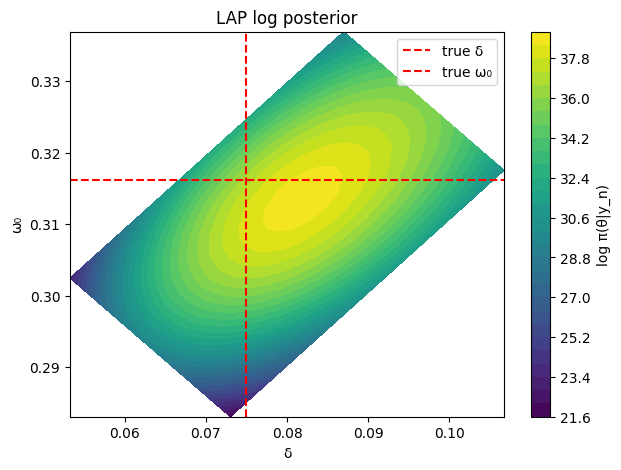

In [38]:
delta_grid_theta  = np.zeros_like(Z0)
omega0_grid_theta = np.zeros_like(Z1)

for i in range(Z0.shape[0]):
    for j in range(Z0.shape[1]):
        print(i)
        z = np.array([Z0[i,j], Z1[i,j]])
        theta_ij = (theta0 + A @ z).numpy()
        delta_grid_theta[i][j]  = theta_ij[0]
        omega0_grid_theta[i][j] = theta_ij[1]
print(delta_grid)
pp.figure(figsize=(7,5))
pp.contourf(delta_grid_theta, omega0_grid_theta, log_pi, levels=30, cmap='viridis')
pp.colorbar(label='log π(θ|y_n)')
pp.axvline(delta_msd,  color='r', linestyle='--', label='true δ')
pp.axhline(omega0_msd, color='r', linestyle='--', label='true ω₀')
pp.xlabel('δ'); pp.ylabel('ω₀')
pp.title('LAP log posterior')
pp.legend()

### 13.2 Point Estimates and Uncertainty

In [39]:
delta_mean  = np.average(theta_samples[:,0])
omega0_mean = np.average(theta_samples[:,1])
delta_std   = np.std(theta_samples[:,0])
omega0_std  = np.std(theta_samples[:,1])

print(f"δ:   true={delta_msd:.4f}  est={delta_mean:.4f}  std={delta_std:.4f}")
print(f"ω₀:  true={omega0_msd:.4f}  est={omega0_mean:.4f}  std={omega0_std:.4f}")

δ:   true=0.0750  est=0.0825  std=0.0062
ω₀:  true=0.3162  est=0.3138  std=0.0056


### 13.3 Marginal Posteriors

Text(0.5, 1.0, 'Marginal posterior ω₀')

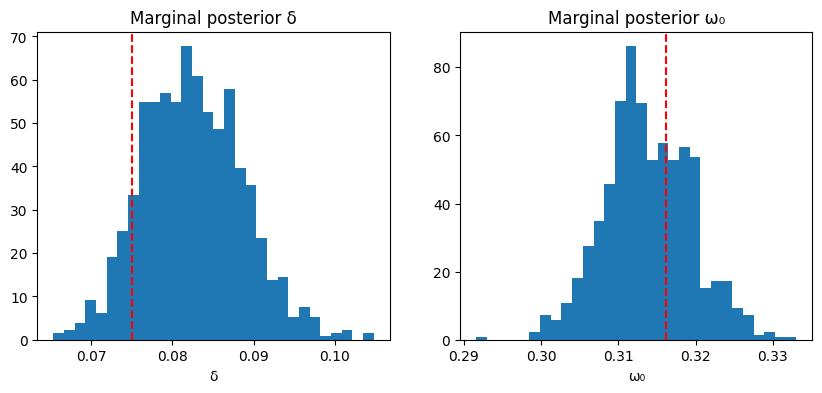

In [40]:
pp.figure(figsize=(10,4))
pp.subplot(1,2,1)
pp.hist(theta_samples[:,0], bins=30, density=True)
pp.axvline(delta_msd, color='r', linestyle='--', label='true δ')
pp.xlabel('δ'); pp.title('Marginal posterior δ')

pp.subplot(1,2,2)
pp.hist(theta_samples[:,1], bins=30, density=True)
pp.axvline(omega0_msd, color='r', linestyle='--', label='true ω₀')
pp.xlabel('ω₀'); pp.title('Marginal posterior ω₀')

### 13.4 Noise Estimate

Since $\tau^2 = 1/\sigma^2$, posterior samples of $\sigma$ are $\sigma^{(i)} = 1/\sqrt{\tau^{2(i)}}$.

In [41]:
delta_ci  = np.percentile(theta_samples[:,0], [2.5, 97.5])
omega0_ci = np.percentile(theta_samples[:,1], [2.5, 97.5])

print(f"δ   95% CI: [{delta_ci[0]:.4f}, {delta_ci[1]:.4f}]  true={delta_msd:.4f}")
print(f"ω₀  95% CI: [{omega0_ci[0]:.4f}, {omega0_ci[1]:.4f}]  true={omega0_msd:.4f}")

δ   95% CI: [0.0713, 0.0952]  true=0.0750
ω₀  95% CI: [0.3029, 0.3250]  true=0.3162


In [42]:
sigma_samples = 1.0 / np.sqrt(tau2_samples)
print(f"σ estimate: {np.mean(sigma_samples):.4f} ± {np.std(sigma_samples):.4f}  true=0.1")

σ estimate: 0.0964 ± 0.0072  true=0.1


### 13.5 Posterior Predictive — MAP Trajectory vs Data

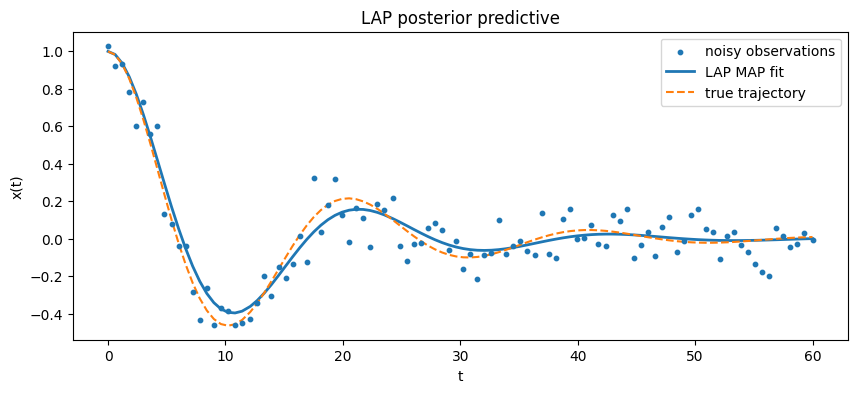

In [43]:
# use MAP estimate
j_map, i_map  = np.unravel_index(np.argmax(pi), pi.shape)
theta_map     = (theta0 + A @ np.array([Z0[j_map,i_map], Z1[j_map,i_map]])).numpy()

f      = functools.partial(msd, delta=theta_map[0], omega0=theta_map[1])
Y_map  = rk4_integrate(f, t_obs, x0, m_sub)

pp.figure(figsize=(10,4))
pp.scatter(t_obs, y_obs.numpy(), s=10, label='noisy observations', zorder=3)
pp.plot(t_obs, Y_map[:,0].detach().numpy(), lw=2, label='LAP MAP fit')
pp.plot(t_obs, y_exact, '--', label='true trajectory')
pp.xlabel('t'); pp.ylabel('x(t)')
pp.title('LAP posterior predictive')
pp.legend()

In [ ]:
def LAP_M2_sweep(theta0, M2):

    H = torch.autograd.functional.hessian(lap_posterior, torch.tensor(theta0, dtype=torch.float64))
    neg_H = -H.numpy()

    # eigendecompose
    eigenvalues, U = np.linalg.eigh(neg_H)
    min_pos     = eigenvalues[eigenvalues > 0].min()
    eigenvalues = np.where(eigenvalues <= 0, min_pos, eigenvalues)
    A              = np.matmul(U, np.diag(eigenvalues ** -0.5))

    # --- Step 2: coarse scan over z ∈ [-4, 4]^q ---
    M1    = 3
    eta   = 1e-5
    z_1d  = np.linspace(-4, 4, 2*M1 + 1)

    A_bounds = []   # will hold [A_i, B_i] for each dimension
    B_bounds = []

    print(z_1d)
    for dim in range(len(theta0)):
        active = []
        for z_val in z_1d:
            z          = np.zeros(len(theta0))
            z[dim]     = z_val
            theta_test = theta0 + A @ z
            lp        = lap_posterior(theta_test)
            if lp > np.log(eta):
                active.append(z_val)
        A_bounds.append(min(active) if active else -4)
        B_bounds.append(max(active) if active else  4)

    print(f"Coarse scan bounds in z-space:")
    for i in range(len(theta0)):
        print(f"  z[{i}]: [{A_bounds[i]:.2f}, {B_bounds[i]:.2f}]")

    M2     = M2
    z0_1d  = np.linspace(A_bounds[0], B_bounds[0], 2*M2 + 1)
    z1_1d  = np.linspace(A_bounds[1], B_bounds[1], 2*M2 + 1)

    Z0, Z1  = np.meshgrid(z0_1d, z1_1d)
    log_pi  = np.zeros_like(Z0)
    u_grid = np.zeros_like(Z0)

    for i in range(Z0.shape[0]):
        for j in range(Z0.shape[1]):
            z          = np.array([Z0[i,j], Z1[i,j]])
            theta_ij   = theta0 + A @ z
            lp, u        = lap_posterior_u(theta_ij)
            log_pi[i,j]  = float(lp)
            u_grid[i,j]  = float(u)
            print(f"({i},{j}) θ=({theta_ij[0]:.3f},{theta_ij[1]:.3f}) → {log_pi[i,j]:.2f}")
    
    # --- normalize ---
    log_pi_shifted = log_pi - np.max(log_pi)   # subtract max for numerical stability
    pi             = np.exp(log_pi_shifted)
    pi            /= pi.sum()                   # proper probability weights

    # --- draw θ^(i) samples from the discrete grid ---
    N_samples   = 1000
    flat_pi     = pi.flatten()
    flat_idx    = np.random.choice(len(flat_pi), size=N_samples, p=flat_pi)
    i_idx, j_idx = np.unravel_index(flat_idx, pi.shape)

    theta_samples = np.array([
        (theta0 + A @ np.array([Z0[i,j], Z1[i,j]]))
        for i, j in zip(i_idx, j_idx)
    ])   # (N_samples, 2)

    # --- Step 3: for each θ^(i), draw τ²^(i) ~ Gamma(np/2+a, u(θ^(i))/2+b) ---
    u_flat     = u_grid.flatten()[flat_idx]
    tau2_samples = np.array([
        np.random.gamma(
            shape = n*p/2 + a,
            scale = 1.0 / (u_flat[i] / 2 + b)
        )
        for i in range(N_samples)
    ])

    lp, u = lap_posterior_u(theta_ij)
    log_pi[i,j] = float(lp)
    u_grid[i,j] = float(u)

    return tau2_samples, theta_samples,Z0, Z1, A, log_pi, u_grid

In [ ]:
import time

M2_values = [3, 5, 10, 20]
results   = []

for M2 in M2_values:
    print(f"\n{'='*40}")
    print(f"M2 = {M2}  ({(2*M2+1)**2} grid points)")
    print('='*40)

    t_start = time.time()
    tau2_samples, theta_samples, Z0, Z1, A, log_pi, u_grid = LAP_M2_sweep(theta0, M2)
    runtime = time.time() - t_start

    d_mean  = np.mean(theta_samples[:,0])
    w_mean  = np.mean(theta_samples[:,1])
    d_bias  = d_mean - delta_msd
    w_bias  = w_mean - omega0_msd
    d_ci    = np.percentile(theta_samples[:,0], [2.5, 97.5])
    w_ci    = np.percentile(theta_samples[:,1], [2.5, 97.5])
    d_width = d_ci[1] - d_ci[0]
    w_width = w_ci[1] - w_ci[0]

    results.append({
        'M2': M2, 'n_grid': (2*M2+1)**2, 'runtime': runtime,
        'd_mean': d_mean,   'w_mean': w_mean,
        'd_bias': d_bias,   'w_bias': w_bias,
        'd_width': d_width, 'w_width': w_width,
    })

    print(f"runtime : {runtime:.1f}s")
    print(f"δ  : mean={d_mean:.4f}  bias={d_bias:+.4f}  95%CI=[{d_ci[0]:.4f},{d_ci[1]:.4f}]  width={d_width:.4f}")
    print(f"ω₀ : mean={w_mean:.4f}  bias={w_bias:+.4f}  95%CI=[{w_ci[0]:.4f},{w_ci[1]:.4f}]  width={w_width:.4f}")

# --- plots ---
M2_vals  = [r['M2']          for r in results]
d_biases = [abs(r['d_bias']) for r in results]
w_biases = [abs(r['w_bias']) for r in results]
d_widths = [r['d_width']     for r in results]
w_widths = [r['w_width']     for r in results]
runtimes = [r['runtime']     for r in results]

fig, axes = pp.subplots(1, 3, figsize=(14, 4))

axes[0].plot(M2_vals, d_biases, 'o-', label='|bias| δ')
axes[0].plot(M2_vals, w_biases, 's-', label='|bias| ω₀')
axes[0].set_xlabel('M2'); axes[0].set_title('Bias vs M2')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(M2_vals, d_widths, 'o-', label='CI width δ')
axes[1].plot(M2_vals, w_widths, 's-', label='CI width ω₀')
axes[1].set_xlabel('M2'); axes[1].set_title('95% CI width vs M2')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(M2_vals, runtimes, 'o-', color='gray')
axes[2].set_xlabel('M2'); axes[2].set_title('Runtime [s] vs M2')
axes[2].grid(True)

pp.suptitle(f'M2 sweep  (true δ={delta_msd:.4f}, ω₀={omega0_msd:.4f})')
pp.tight_layout(); pp.show()

In [44]:
lap_theta_samples = theta_samples        # (1000, 2) numpy array
lap_delta_samples  = theta_samples[:,0]  # numpy array
lap_omega0_samples = theta_samples[:,1]  # numpy array
lap_x_pred        = Y_map[:,0].detach().numpy()  # MAP trajectory
lap_delta_ci      = np.percentile(theta_samples[:,0], [2.5, 97.5])
lap_omega0_ci     = np.percentile(theta_samples[:,1], [2.5, 97.5])
lap_delta_mean    = np.mean(theta_samples[:,0])
lap_omega0_mean   = np.mean(theta_samples[:,1])

# Save to file
np.savez('lap_results.npz',
    delta_samples  = lap_delta_samples,
    omega0_samples = lap_omega0_samples,
    x_pred         = lap_x_pred,
    t_obs          = t_obs.numpy(),
    y_obs          = y_obs.numpy(),
)